# Payne Zero from stellar labels to observed spectra

This tutorial follows one physical forward model from stellar labels to an intrinsic spectrum, an instrument-sampled spectrum, a recovered mock label, and a calibrated atomic line. It also shows the three atmosphere initializer families and the difference between a fast initialized atmosphere and a converged physical atmosphere.

The examples are deliberately small enough for a laptop. CUDA is preferred for wide production windows, Apple Metal is useful for local work, and every calculation retains a CPU path.


In [1]:
from pathlib import Path
import json
import os

repo = Path.cwd().resolve()
output_dir = repo / "tutorial_output"
output_dir.mkdir(exist_ok=True)
os.environ.setdefault(
    "PAYNE_ZERO_SYNTHESIS_CACHE_DIR",
    str(output_dir / "synthesis_source_cache"),
)
os.environ.setdefault(
    "PAYNE_ZERO_NUMBA_CACHE_DIR",
    str(output_dir / "numba_cache"),
)

import matplotlib.pyplot as plt
import numpy as np
import torch

requested = os.getenv("PAYNE_ZERO_DEVICE", "auto")
if requested == "auto":
    device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )
else:
    device = requested
dtype_name = "float64" if device == "cpu" else "float32"
torch_dtype = torch.float64 if dtype_name == "float64" else torch.float32

COLORS = {
    "navy": "#284B63",
    "blue": "#4C78A8",
    "orange": "#E07A5F",
    "green": "#4C956C",
    "grey": "#6B7280",
    "light": "#D9E2EC",
}
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "lines.linewidth": 1.35,
    }
)
print(f"device={device}, dtype={dtype_name}")


device=mps, dtype=float32


## 1. Three atmosphere families

`synthesize_from_labels` is the usual starting point. The five-label family varies effective temperature, surface gravity, overall metallicity, a shared alpha enhancement, and microturbulence. Adding `[C/M]`, `[N/M]`, and `[O/M]` selects the eight-label family. The direct-abundance family replaces the bulk chemical coordinates with `[Fe/H]` and any individual `[X/H]` values. Unspecified elements inherit `[Fe/H]`.

Each call below predicts a complete depth structure, reconstructs its populations, and performs physical synthesis. The returned atmosphere is initialized but has not yet passed the iterative atmosphere convergence test.


In [2]:
from payne_zero_synthesis import synthesize_from_labels

common_giant = dict(
    effective_temperature=4600.0,
    log_surface_gravity=2.2,
    microturbulence_km_s=1.6,
    wavelength_start_nm=1567.75,
    wavelength_end_nm=1568.65,
    r_grid=180_000,
    device=device,
    dtype=dtype_name,
)
five_label = synthesize_from_labels(
    metallicity=-0.4,
    alpha_enhancement=0.2,
    **common_giant,
)
eight_label = synthesize_from_labels(
    metallicity=-0.4,
    alpha_enhancement=0.2,
    c_over_m=-0.25,
    n_over_m=0.35,
    o_over_m=0.15,
    **common_giant,
)
direct = synthesize_from_labels(
    fe_over_h=-0.4,
    x_over_h={"C": -0.65, "N": -0.05, "O": -0.25, "Mg": -0.15},
    initializer_family="direct_abundance",
    **common_giant,
)

for result in (five_label, eight_label, direct):
    print(
        f"{result.initializer_family:18s} "
        f"{result.wavelength_nm.size:4d} pixels, "
        f"{result.seconds:.2f} s total, "
        f"converged={result.atmosphere_converged}"
    )


five_label          103 pixels, 9.10 s total, converged=False
cno8                103 pixels, 4.66 s total, converged=False
direct_abundance    103 pixels, 4.80 s total, converged=False


The spectra differ because the chemical mixture changes both the initialized atmosphere and the line opacity. The direct family is useful when a bulk `[M/H]` or `[alpha/M]` coordinate is too restrictive. Its higher-dimensional initializer is a starting model rather than a substitute for physical convergence.


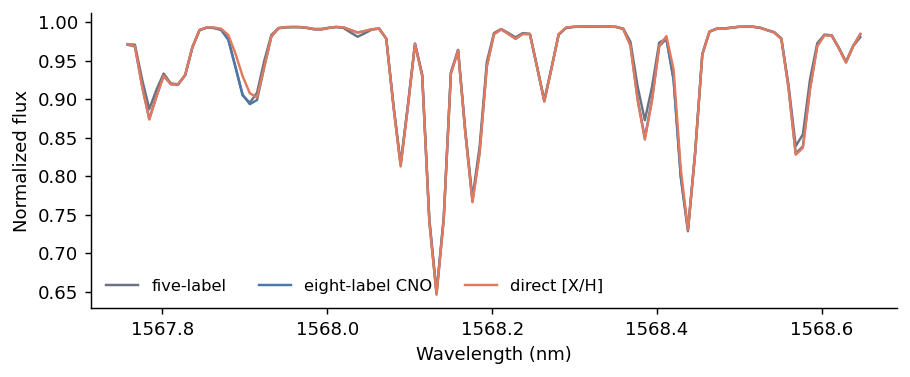

In [3]:
fig, ax = plt.subplots(figsize=(7.1, 3.0))
for result, label, color in (
    (five_label, "five-label", COLORS["grey"]),
    (eight_label, "eight-label CNO", COLORS["blue"]),
    (direct, "direct [X/H]", COLORS["orange"]),
):
    ax.plot(result.wavelength_nm, result.normalized_flux, label=label, color=color)
ax.set(xlabel="Wavelength (nm)", ylabel="Normalized flux")
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
plt.show()


## 2. Initialized and converged atmospheres

Repeated searches can use the initialized atmosphere. A final physical atmosphere is obtained by iterating the structure at the requested labels until the convergence tests pass. The public solver writes the same structured archive consumed by synthesis.

The cell uses the bundled converged solar atmosphere so the notebook remains quick. Set `PAYNE_ZERO_RUN_ATMOSPHERE=1` to solve it again. The explicit branch shows the production API rather than a separate tutorial implementation.


In [4]:
from payne_zero_atmosphere import solve_structured_atmosphere
from payne_zero_synthesis import synthesize

physical_path = repo / "examples" / "data" / "sun_structured_atmosphere.npz"
if os.getenv("PAYNE_ZERO_RUN_ATMOSPHERE", "0") == "1":
    physical_path = solve_structured_atmosphere(
        effective_temperature=5777.0,
        log_surface_gravity=4.44,
        metallicity=0.0,
        alpha_enhancement=0.0,
        microturbulence_km_s=1.0,
        out_dir=output_dir / "solar_atmosphere",
    )

solar_common = dict(
    wavelength_start_nm=500.0,
    wavelength_end_nm=502.0,
    device=device,
    dtype=dtype_name,
)
initialized_sun = synthesize_from_labels(
    effective_temperature=5777.0,
    log_surface_gravity=4.44,
    metallicity=0.0,
    alpha_enhancement=0.0,
    microturbulence_km_s=1.0,
    r_grid=60_000,
    **solar_common,
)
physical_sun = synthesize(
    physical_path,
    resolution=60_000,
    **solar_common,
)
print(
    "initialized flags:",
    initialized_sun.atmosphere_converged,
    initialized_sun.atmosphere_closure_required,
)
print("converged atmosphere:", physical_path)


initialized flags: False True
converged atmosphere: /Users/ysting/payne-zero/examples/data/sun_structured_atmosphere.npz


The initialized and converged spectra share the broad line pattern, but individual depths can differ materially. This is why the initialized atmosphere is useful for a fast local search while the converged atmosphere remains the final physical check. Payne Zero records this distinction in label-driven spectrum products and in explicitly saved initialized-atmosphere products.


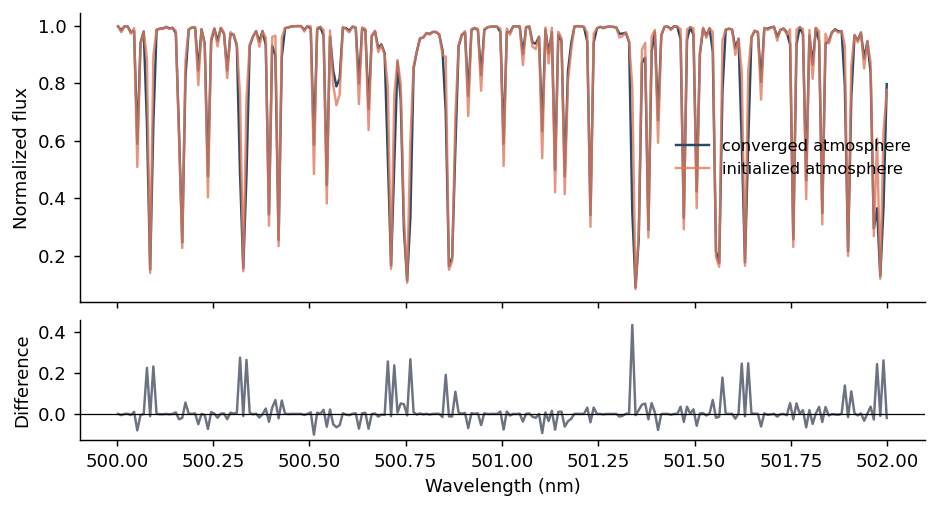

In [5]:
fig, (top, bottom) = plt.subplots(
    2,
    1,
    figsize=(7.1, 3.8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.4, 1.0]},
    constrained_layout=True,
)
top.plot(
    physical_sun.wavelength_nm,
    physical_sun.normalized_flux,
    color=COLORS["navy"],
    label="converged atmosphere",
)
top.plot(
    initialized_sun.wavelength_nm,
    initialized_sun.normalized_flux,
    color=COLORS["orange"],
    alpha=0.8,
    label="initialized atmosphere",
)
difference = initialized_sun.normalized_flux - physical_sun.normalized_flux
bottom.plot(physical_sun.wavelength_nm, difference, color=COLORS["grey"])
bottom.axhline(0.0, color="black", lw=0.7)
top.set_ylabel("Normalized flux")
bottom.set(xlabel="Wavelength (nm)", ylabel="Difference")
top.legend(frameon=False)
plt.show()


## 3. Map an intrinsic spectrum to observed pixels

Synthesis returns a uniform logarithmic wavelength grid. An observation also requires velocity registration, broadening, a line-spread function, and resampling. `ObservedSpectrumOperator` performs these steps on the same Torch device. It accepts either a constant resolving power or a sampled shift-invariant kernel. A survey with a wavelength-dependent LSF can provide an object with the same `convolve_fluxes` interface.


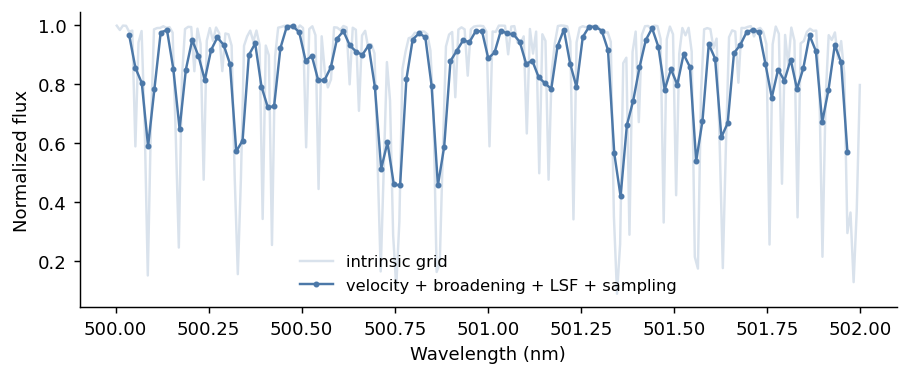

In [6]:
from fitter import ObservedSpectrumOperator

observed_wavelength = np.linspace(
    physical_sun.wavelength_nm[4],
    physical_sun.wavelength_nm[-5],
    115,
)
instrument = ObservedSpectrumOperator(
    physical_sun.wavelength_nm,
    observed_wavelength,
    resolving_power=25_000,
    device=device,
    dtype=torch_dtype,
)
instrument.set_parameters(
    radial_velocity_km_s=2.0,
    broadening_sigma_km_s=3.0,
)
projected_total, projected_continuum, projected_normalized = (
    instrument.convolve_fluxes(
        torch.as_tensor(
            physical_sun.flux_total, device=device, dtype=torch_dtype
        ),
        torch.as_tensor(
            physical_sun.flux_continuum, device=device, dtype=torch_dtype
        ),
    )
)
projected_normalized = projected_normalized.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(7.1, 3.0))
ax.plot(
    physical_sun.wavelength_nm,
    physical_sun.normalized_flux,
    color=COLORS["light"],
    label="intrinsic grid",
)
ax.plot(
    observed_wavelength,
    projected_normalized,
    color=COLORS["blue"],
    marker="o",
    ms=2.3,
    label="velocity + broadening + LSF + sampling",
)
ax.set(xlabel="Wavelength (nm)", ylabel="Normalized flux")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 4. Recover a label from a mock spectrum

The generic fitter only requires observed arrays, parameter bounds, and a forward callback. Here the mock truth and every trial are generated by Payne Zero. A finite-difference response estimates how the spectrum changes with metallicity, and a bounded local step updates the label. No label-to-flux emulator is used.

The example is normalized, so it does not fit a continuum. For a reduced spectrum, pass a low-order basis through `continuum_basis`; the fitter then profiles those linear coefficients at every trial.


In [7]:
from fitter import (
    FitConfiguration,
    NormalizedSpectrum,
    fit_normalized_spectrum,
)

mock_common = dict(
    effective_temperature=4750.0,
    log_surface_gravity=2.5,
    alpha_enhancement=0.15,
    microturbulence_km_s=1.5,
    wavelength_start_nm=515.0,
    wavelength_end_nm=517.0,
    r_grid=30_000,
    device=device,
    dtype=dtype_name,
)
native_template = synthesize_from_labels(metallicity=-0.3, **mock_common)
mock_wavelength = np.linspace(
    native_template.wavelength_nm[3],
    native_template.wavelength_nm[-4],
    120,
)
mock_instrument = ObservedSpectrumOperator(
    native_template.wavelength_nm,
    mock_wavelength,
    resolving_power=25_000,
    device=device,
    dtype=torch_dtype,
)

def metallicity_model(parameters):
    return synthesize_from_labels(
        metallicity=float(parameters[0]),
        spectral_operator=mock_instrument,
        **mock_common,
    ).normalized_flux

truth_metallicity = -0.30
noiseless_mock = metallicity_model(np.array([truth_metallicity]))
rng = np.random.default_rng(20260724)
sigma = 1.0 / 400.0
observed_mock = noiseless_mock + rng.normal(0.0, sigma, noiseless_mock.size)
mock_data = NormalizedSpectrum(
    wavelength=mock_wavelength,
    flux=observed_mock,
    inverse_variance=np.full(mock_wavelength.size, sigma**-2),
    mask=np.ones(mock_wavelength.size, dtype=bool),
)
fit_config = FitConfiguration(
    names=("M_H",),
    initial=np.array([-0.05]),
    lower=np.array([-1.0]),
    upper=np.array([0.3]),
    derivative_steps=np.array([0.05]),
    trust_half_width=np.array([0.30]),
    maximum_iterations=4,
)
mock_fit = fit_normalized_spectrum(
    mock_data,
    fit_config,
    metallicity_model,
)
print(f"truth [M/H] = {truth_metallicity:+.3f}")
print(f"fitted [M/H] = {mock_fit.parameters[0]:+.3f}")
print(f"stop = {mock_fit.stop_reason}")


truth [M/H] = -0.300
fitted [M/H] = -0.295
stop = line_search


The upper panel compares the recovered physical spectrum with the mock observation. The residual panel uses the known injected uncertainty. A multi-label fit uses the same callback with a longer parameter vector.


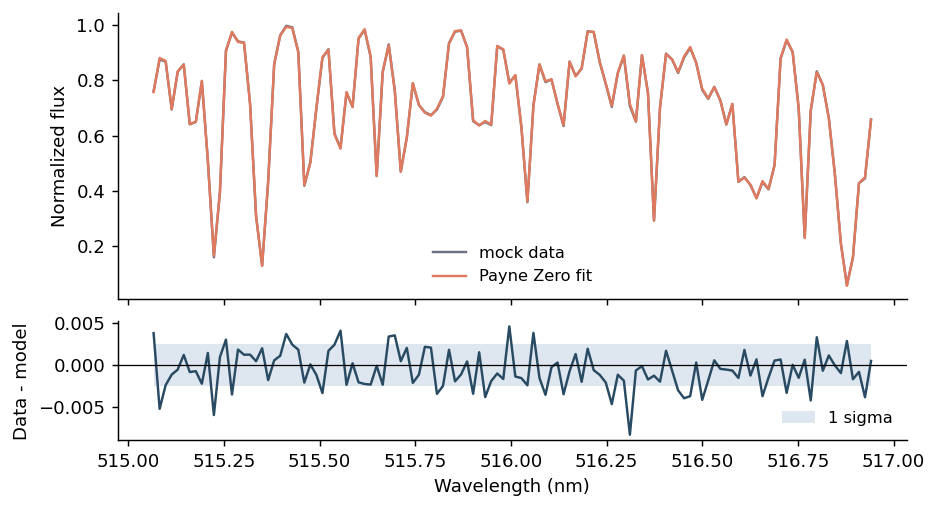

In [8]:
fit_residual = observed_mock - mock_fit.model_flux
fig, (top, bottom) = plt.subplots(
    2,
    1,
    figsize=(7.1, 3.8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.4, 1.0]},
    constrained_layout=True,
)
top.plot(mock_wavelength, observed_mock, color=COLORS["grey"], label="mock data")
top.plot(
    mock_wavelength,
    mock_fit.model_flux,
    color=COLORS["orange"],
    label="Payne Zero fit",
)
bottom.plot(mock_wavelength, fit_residual, color=COLORS["navy"])
bottom.fill_between(
    mock_wavelength,
    -sigma,
    sigma,
    color=COLORS["blue"],
    alpha=0.18,
    linewidth=0,
    label="1 sigma",
)
bottom.axhline(0.0, color="black", lw=0.7)
top.set_ylabel("Normalized flux")
bottom.set(xlabel="Wavelength (nm)", ylabel="Data - model")
top.legend(frameon=False)
bottom.legend(frameon=False)
plt.show()


## 5. Calibrate an atomic line with a real FTS spectrum

Line-list calibration keeps a standard-star atmosphere fixed and differentiates physical synthesis with respect to selected atomic parameters. The bundled example uses a solar Fourier-transform-spectrometer atlas excerpt and one Fe I transition near 1568.18 nm. The unchanged opacity is prepared once; repeated iterations recalculate the selected line and transfer solution.


In [9]:
from linelist_calibration import calibrate_line_parameters
from linelist_calibration.examples.fit_solar_fts_line import build_example

fts_data, fts_config, fts_model, fts_metadata = build_example(
    device=device,
    dtype=dtype_name,
    maximum_iterations=30,
)
fts_callback = fts_model.callback(("loggf",))
fts_baseline = fts_model.baseline_flux(("loggf",))
fts_result = calibrate_line_parameters(
    fts_data,
    fts_config,
    fts_callback,
)
fitted_tensor = torch.as_tensor(
    fts_result.values,
    device=fts_model.device,
    dtype=fts_model.dtype,
)
with torch.no_grad():
    fts_calibrated = fts_callback(fitted_tensor).detach().cpu().numpy()
fts_overlay = fts_model.write_atomic_calibration_overlay(
    fts_result.values,
    output_dir / "solar_fts_fe_line_overlay.npz",
    parameter_families=("loggf",),
    calibration_name="tutorial_solar_fts_fe_line",
)
print(fts_metadata["atlas"])
print(f"delta log(gf) = {fts_result.values[0]:+.3f} dex")
print(
    f"objective = {fts_result.initial_loss:.4g} "
    f"to {fts_result.final_loss:.4g}"
)
print("overlay:", fts_overlay["overlay_path"])


Livingston & Wallace (1991) solar center-of-disk infrared atlas
delta log(gf) = +0.801 dex
objective = 0.005137 to 0.001105
overlay: /Users/ysting/payne-zero/tutorial_output/solar_fts_fe_line_overlay.npz


The correction is an additive change in dex. The same model accepts several transitions and the damping families `vdw`, `radiative`, and `stark`. Another FTS atlas or Gaia benchmark star uses its own converged atmosphere, wavelength array, weights, velocity registration, and broadening kernel.


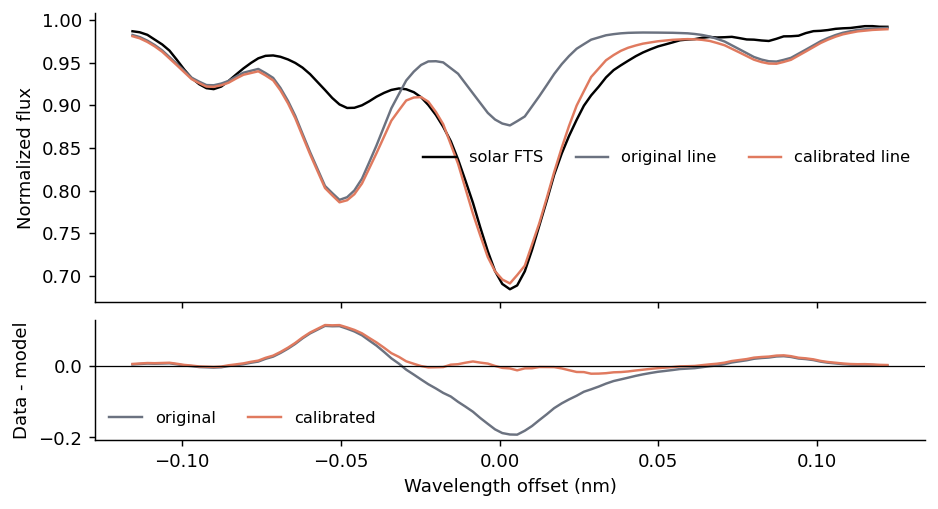

In [10]:
fts_wavelength = fts_model.output_wavelength_nm
fts_observed = np.asarray(fts_data.flux)
fts_delta = fts_wavelength - fts_model.transitions[0].wavelength_nm
fig, (top, bottom) = plt.subplots(
    2,
    1,
    figsize=(7.1, 3.8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.4, 1.0]},
    constrained_layout=True,
)
top.plot(fts_delta, fts_observed, color="black", label="solar FTS")
top.plot(fts_delta, fts_baseline, color=COLORS["grey"], label="original line")
top.plot(
    fts_delta,
    fts_calibrated,
    color=COLORS["orange"],
    label="calibrated line",
)
bottom.plot(
    fts_delta,
    fts_observed - fts_baseline,
    color=COLORS["grey"],
    label="original",
)
bottom.plot(
    fts_delta,
    fts_observed - fts_calibrated,
    color=COLORS["orange"],
    label="calibrated",
)
bottom.axhline(0.0, color="black", lw=0.7)
top.set_ylabel("Normalized flux")
bottom.set(xlabel="Wavelength offset (nm)", ylabel="Data - model")
top.legend(frameon=False, ncol=3)
bottom.legend(frameon=False, ncol=2)
plt.show()


## 6. APOGEE with a wavelength-dependent LSF and continuum

The APOGEE adapter replaces the simple constant-resolution operator with a measured wavelength-dependent line-spread function. Its compact kernels stay on the selected device and jointly convolve total and continuum flux before normalization. The fitted model also includes residual velocity, Gaussian broadening, and one profiled low-order continuum per detector segment.

The next cells use a prepared result made by the public `fit_apogee_spectrum` entry point. Set `PAYNE_ZERO_RUN_APOGEE=1` to repeat the full fit; on a CPU that is intentionally much slower than the tutorial plots.


In [11]:
from fitter.apogee import fit_apogee_spectrum

with np.load(repo / "examples" / "data" / "apogee_dr14_example.npz") as source:
    apogee = {name: np.asarray(source[name]) for name in source.files}
apogee_metadata = json.loads(
    (repo / "examples" / "data" / "apogee_dr14_example.json").read_text()
)
with np.load(
    repo / "examples" / "data" / "apogee_dr14_fit_reference.npz"
) as source:
    apogee_reference = {
        name: np.asarray(source[name]) for name in source.files
    }

if os.getenv("PAYNE_ZERO_RUN_APOGEE", "0") == "1":
    fit_apogee_spectrum(
        output_dir / "apogee_fit",
        object_id=apogee_metadata["object_id"],
        wavelength_nm=apogee["wavelength_nm"],
        normalized_flux=apogee["normalized_flux"],
        inverse_variance=apogee["inverse_variance"],
        good_pixel_mask=apogee["good_pixel_mask"],
        reference_labels=np.array(
            [
                apogee_metadata["effective_temperature"],
                apogee_metadata["log_surface_gravity"],
                apogee_metadata["metallicity"],
                apogee_metadata["alpha_enhancement"],
                apogee_metadata["microturbulence_km_s"],
            ]
        ),
        reference_vmacro_km_s=apogee_metadata[
            "macroscopic_broadening_km_s"
        ],
        atomic_calibration_path=(
            repo
            / "linelist_calibration"
            / "data"
            / "sun_arcturus_fts_hband_shared.npz"
        ),
        device=device,
        dtype=dtype_name,
        force=True,
    )

fit_metadata = json.loads(str(apogee_reference["metadata_json"]))
print(apogee_metadata["object_id"])
print(fit_metadata["instrument_operator"])


2M08002084+4044415
APOGEE DR14 all-slit mean line-spread function


The LSF asset tabulates a different kernel at each retained apStar pixel. The left panel shows three representative kernels. The right panel shows a line-rich interval from the prepared fit. The uncertainty band is the reported one-sigma flux uncertainty, and the residual uses the same continuum-profiled, LSF-convolved model shown above it.


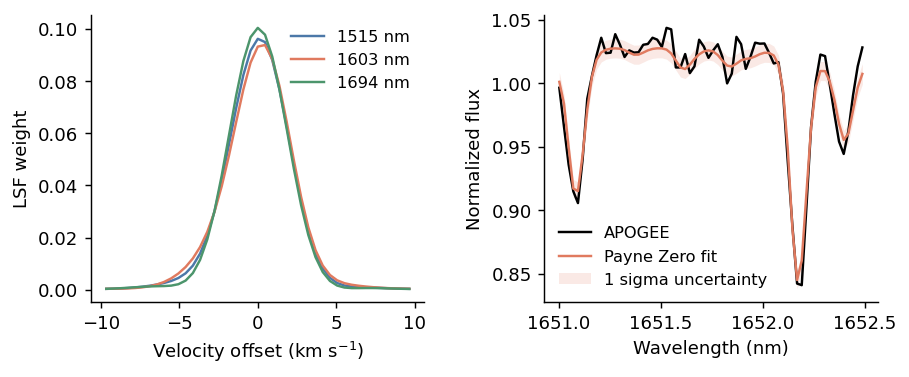

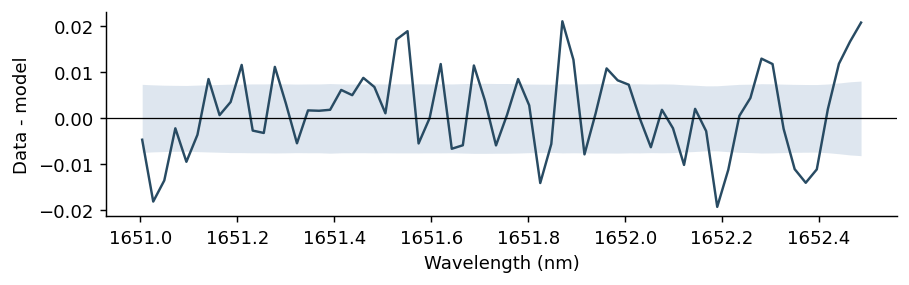

In [12]:
with np.load(
    repo / "fitter" / "apogee" / "data" / "apogee_dr14_combo_lsf.npz"
) as lsf_asset:
    taps = np.asarray(lsf_asset["tap_offset_oversampled_pixel"], np.float64)
    kernels = np.asarray(lsf_asset["kernel_weights"], np.float64)
    lsf_wavelength = np.asarray(lsf_asset["wavelength_nm"], np.float64)
tap_velocity = taps * (np.log(10.0) * 2.0e-6 / 3.0) * 299_792.458

wavelength = apogee["wavelength_nm"]
observed = apogee["normalized_flux"]
error = apogee["normalized_error"]
model = apogee_reference["normalized_model_flux"]
good = apogee["good_pixel_mask"]
region = (wavelength > 1651.0) & (wavelength < 1652.5) & good

fig, (left, right) = plt.subplots(1, 2, figsize=(7.1, 3.0))
for index, color in zip(
    (0, len(lsf_wavelength) // 2, -1),
    (COLORS["blue"], COLORS["orange"], COLORS["green"]),
):
    left.plot(
        tap_velocity,
        kernels[index],
        color=color,
        label=f"{lsf_wavelength[index]:.0f} nm",
    )
left.set(xlabel="Velocity offset (km s$^{-1}$)", ylabel="LSF weight")
left.legend(frameon=False)

right.plot(wavelength[region], observed[region], color="black", label="APOGEE")
right.plot(
    wavelength[region],
    model[region],
    color=COLORS["orange"],
    label="Payne Zero fit",
)
right.fill_between(
    wavelength[region],
    model[region] - error[region],
    model[region] + error[region],
    color=COLORS["orange"],
    alpha=0.16,
    linewidth=0,
    label="1 sigma uncertainty",
)
right.set(xlabel="Wavelength (nm)", ylabel="Normalized flux")
right.legend(frameon=False)
fig.tight_layout(w_pad=2.2)
plt.show()

residual = observed[region] - model[region]
fig, ax = plt.subplots(figsize=(7.1, 2.3))
ax.plot(wavelength[region], residual, color=COLORS["navy"])
ax.fill_between(
    wavelength[region],
    -error[region],
    error[region],
    color=COLORS["blue"],
    alpha=0.18,
    linewidth=0,
)
ax.axhline(0.0, color="black", lw=0.7)
ax.set(xlabel="Wavelength (nm)", ylabel="Data - model")
fig.tight_layout()
plt.show()


## 7. Adapting the workflow

For another reduced spectrum, keep the label callback and replace only the observation arrays and instrument operator. A constant-resolution survey can use `ObservedSpectrumOperator`; a wavelength-dependent LSF implements `output_wavelength_nm` and `convolve_fluxes(total_flux, continuum_flux)`. Add a Legendre or other low-order basis only when the reduction still requires continuum profiling.

For another standard star, construct `SynthesisLineCalibrationModel` with that star's converged atmosphere and atlas arrays, choose the transitions and parameter families, optimize, and export the resulting correction overlay or a substituted local catalog. Joint calibration concatenates several standard-star callbacks so one atomic correction must explain every atmosphere.

The fast initialized atmosphere is appropriate for repeated local exploration. The converged physical atmosphere is the final check when atmospheric consistency matters. These two roles use the same synthesis and instrument interfaces, which keeps the path from stellar labels to observed pixels explicit.
